**PHASE 1**

In [2]:
# Cell 1: Run this, then restart runtime (Runtime → Restart runtime)
!pip uninstall numpy -y -q
!pip install -q "numpy<2.0.0" scikit-surprise requests matplotlib seaborn

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version

## Data Loading
Data sourced from McAuley Lab Amazon Reviews dataset via Stanford SNAP.
Run the download cells below only on first use.
Subsequently load directly from shared Drive.

In [1]:
# Data sourced from McAuley Lab Amazon Reviews dataset (Stanford SNAP)
from google.colab import drive
import pandas as pd

drive.mount('/content/drive')

# Loading pre-processed data from Drive
df_filtered = pd.read_csv('/content/drive/MyDrive/Group_Rec_Engines_Project/amazon_electronics_filtered.csv')
df_meta = pd.read_csv('/content/drive/MyDrive/Group_Rec_Engines_Project/amazon_meta_filtered.csv')

print(f"Reviews loaded: {len(df_filtered):,}")
print(f"Products loaded: {len(df_meta):,}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Reviews loaded: 2,109,869
Products loaded: 145,199


## Preprocessing Summary

**Raw dataset:** 7,824,482 reviews | 4,201,696 users | 476,002 items  
**Method:** 5-core filtering — retained only users and items with ≥ 5 interactions  
**After filtering:** 2,109,869 reviews | 253,994 users | 145,199 items  
**Sparsity:** 99.9943%  
**Processed on:** 06/04/2026 and saved to shared Drive

=== DATASET OVERVIEW ===
Total interactions: 2,109,869
Unique users:       253,994
Unique items:       145,199
Rating range:       1.0 – 5.0
Avg rating:         4.19
Matrix sparsity:    99.9943%


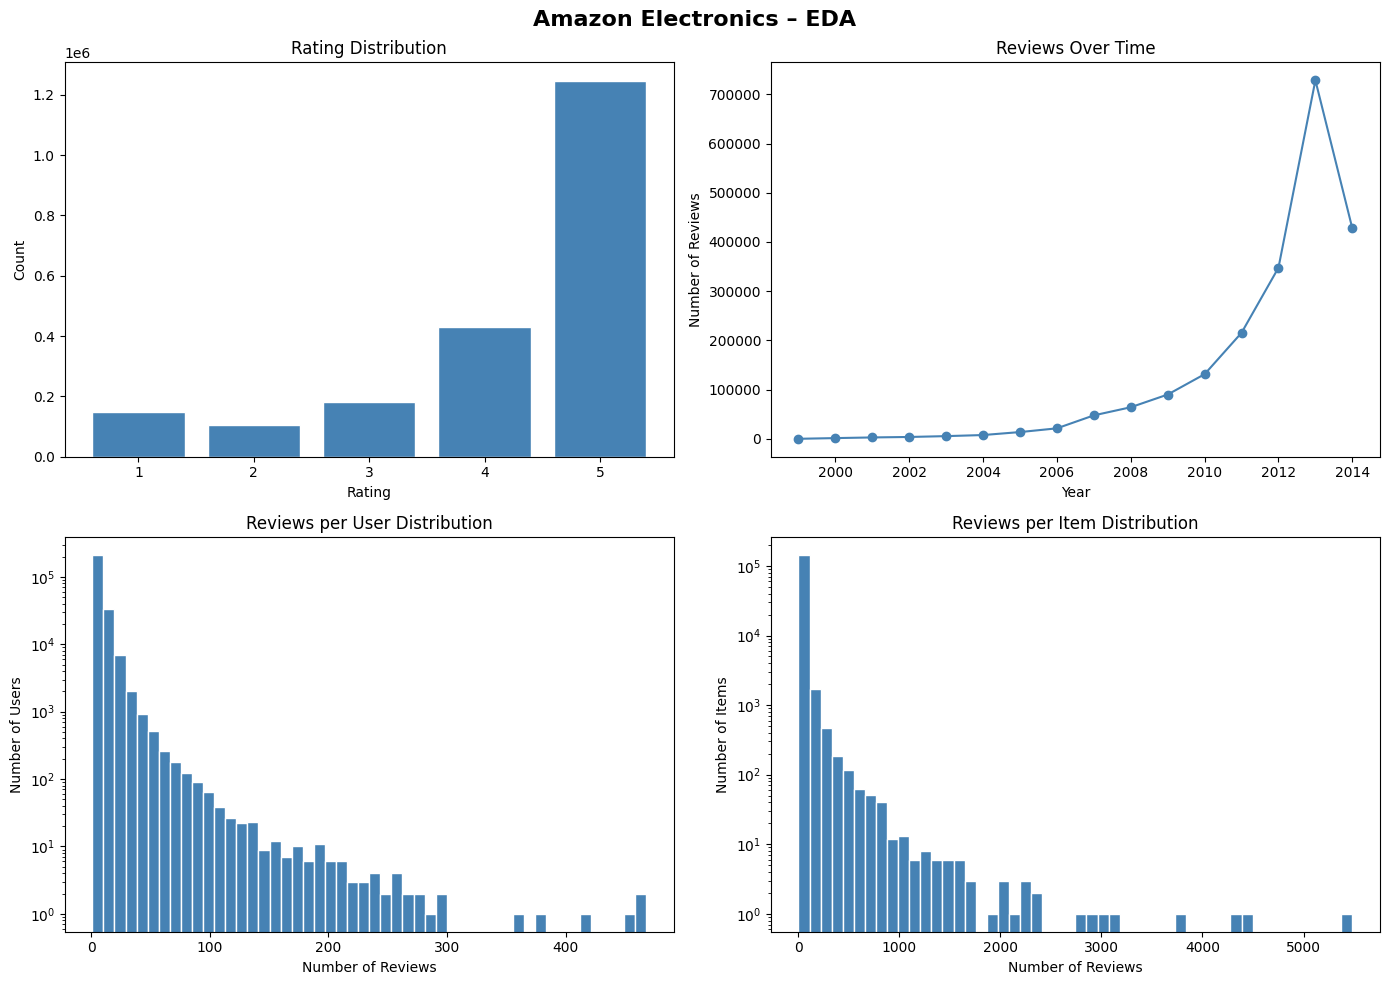

Plot saved to Drive!


In [2]:
#PERFORMING EDA WITH VISUALIZATIONS

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime


# ── 1. Basic stats ──────────────────────────────────────────
print("=== DATASET OVERVIEW ===")
print(f"Total interactions: {len(df_filtered):,}")
print(f"Unique users:       {df_filtered['user_id'].nunique():,}")
print(f"Unique items:       {df_filtered['item_id'].nunique():,}")
print(f"Rating range:       {df_filtered['rating'].min()} – {df_filtered['rating'].max()}")
print(f"Avg rating:         {df_filtered['rating'].mean():.2f}")

# Sparsity (key metric for recommender systems)
n_users = df_filtered['user_id'].nunique()
n_items = df_filtered['item_id'].nunique()
sparsity = 1 - (len(df_filtered) / (n_users * n_items))
print(f"Matrix sparsity:    {sparsity:.4%}")

# ── 2. Convert timestamp ────────────────────────────────────
df_filtered['datetime'] = pd.to_datetime(df_filtered['timestamp'], unit='s')
df_filtered['year']     = df_filtered['datetime'].dt.year
df_filtered['month']    = df_filtered['datetime'].dt.month
df_filtered['dayofweek']= df_filtered['datetime'].dt.dayofweek

# ── 3. Plots ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Amazon Electronics – EDA', fontsize=16, fontweight='bold')

# Plot 1: Rating distribution
axes[0,0].bar(df_filtered['rating'].value_counts().sort_index().index,
              df_filtered['rating'].value_counts().sort_index().values,
              color='steelblue', edgecolor='white')
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Count')

# Plot 2: Reviews per year
yearly = df_filtered['year'].value_counts().sort_index()
axes[0,1].plot(yearly.index, yearly.values, marker='o', color='steelblue')
axes[0,1].set_title('Reviews Over Time')
axes[0,1].set_xlabel('Year')
axes[0,1].set_ylabel('Number of Reviews')

# Plot 3: Reviews per user distribution
user_activity = df_filtered['user_id'].value_counts()
axes[1,0].hist(user_activity.values, bins=50, color='steelblue', edgecolor='white')
axes[1,0].set_title('Reviews per User Distribution')
axes[1,0].set_xlabel('Number of Reviews')
axes[1,0].set_ylabel('Number of Users')
axes[1,0].set_yscale('log')

# Plot 4: Reviews per item distribution
item_activity = df_filtered['item_id'].value_counts()
axes[1,1].hist(item_activity.values, bins=50, color='steelblue', edgecolor='white')
axes[1,1].set_title('Reviews per Item Distribution')
axes[1,1].set_xlabel('Number of Reviews')
axes[1,1].set_ylabel('Number of Items')
axes[1,1].set_yscale('log')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Group_Rec_Engines_Project/eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved to Drive!")

In [3]:
# Metadata sourced from McAuley Lab Amazon Reviews dataset (Stanford SNAP)
# Original source: http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/meta_Electronics.json.gz
# Pre-processed and saved to shared Drive on 06/04/2026

# Metadata already loaded in cell 2 above as df_meta
print(f"Metadata shape: {df_meta.shape}")
print(f"Columns: {df_meta.columns.tolist()}")
print(f"\nSample:\n{df_meta.head(3)}")

Metadata shape: (145199, 6)
Columns: ['asin', 'title', 'description', 'categories', 'price', 'brand']

Sample:
         asin                                              title  \
0  0511189877  CLIKR-5 Time Warner Cable Remote Control UR5U-...   
1  0528881469  Rand McNally 528881469 7-inch Intelliroute TND...   
2  0594451647  Barnes &amp; Noble HDTV Adapter Kit for NOOK H...   

                                         description  \
0  The CLIKR-5 UR5U-8780L remote control is desig...   
1  Like its award-winning predecessor, the Intell...   
2  HDTV Adapter Kit for NOOK HD and NOOK HD+\nThi...   

                                          categories   price brand  
0  [['Electronics', 'Accessories & Supplies', 'Au...   23.36   NaN  
1  [['Electronics', 'GPS & Navigation', 'Vehicle ...  299.99   NaN  
2  [['Electronics', 'Computers & Accessories', 'T...   49.95   NaN  


In [4]:
# Keep only items that exist in our filtered reviews
valid_items = set(df_filtered['item_id'].unique())
df_meta_filtered = df_meta[df_meta['asin'].isin(valid_items)].copy()

# Keep only useful columns
df_meta_filtered = df_meta_filtered[['asin', 'title', 'description', 'categories', 'price', 'brand']]

# Quick summary
print(f"Products in metadata: {len(df_meta_filtered):,}")
print(f"Missing titles: {df_meta_filtered['title'].isna().sum():,}")
print(f"Missing prices: {df_meta_filtered['price'].isna().sum():,}")
print(f"Missing descriptions: {df_meta_filtered['description'].isna().sum():,}")

# Save to Drive
df_meta_filtered.to_csv('/content/drive/MyDrive/Group_Rec_Engines_Project/amazon_meta_filtered.csv', index=False)
print("\nSaved to Drive!")

Products in metadata: 145,199
Missing titles: 2,657
Missing prices: 17,964
Missing descriptions: 16,982

Saved to Drive!


**PHASE 2**

In [5]:
# PHASE 2 — RECOMMENDER SYSTEMS IMPLEMENTATION
# ══════════════════════════════════════════════════════════════

import gc
import ast
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict

# Surprise and Scikit-learn imports
from surprise import Dataset, Reader, KNNBaseline, SVD, accuracy
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler, MultiLabelBinarizer
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics.pairwise import cosine_similarity as sk_cosine
from scipy.sparse import csr_matrix, hstack, issparse

warnings.filterwarnings('ignore')
np.random.seed(42)

print(f"Libraries loaded successfully. Using NumPy: {np.__version__}")

Libraries loaded successfully. Using NumPy: 1.26.4


# Train / Test Split (Temporal)
We use a temporal split (80% train / 20% test) to simulate a realistic deployment scenario where models are trained on historical data and evaluated on future interactions. This avoids information leakage that would occur with a random split.

In [6]:
# ── Temporal 80/20 split ──────────────────────────────────────
df_sorted = df_filtered.sort_values('timestamp').reset_index(drop=True)
split_idx = int(len(df_sorted) * 0.8)

train_df = df_sorted.iloc[:split_idx].copy()
test_df  = df_sorted.iloc[split_idx:].copy()

# Stats
train_users = set(train_df['user_id'].unique())
train_items = set(train_df['item_id'].unique())
test_users  = set(test_df['user_id'].unique())
test_items  = set(test_df['item_id'].unique())

cold_users = test_users - train_users
cold_items = test_items - train_items

print("=== TRAIN / TEST SPLIT ===")
print(f"Train: {len(train_df):,} interactions | {len(train_users):,} users | {len(train_items):,} items")
print(f"Test:  {len(test_df):,} interactions | {len(test_users):,} users | {len(test_items):,} items")
print(f"\nCold-start users (in test only): {len(cold_users):,}")
print(f"Cold-start items (in test only): {len(cold_items):,}")
print(f"\nTrain period: {pd.to_datetime(train_df['timestamp'].min(), unit='s').date()} → {pd.to_datetime(train_df['timestamp'].max(), unit='s').date()}")
print(f"Test  period: {pd.to_datetime(test_df['timestamp'].min(), unit='s').date()} → {pd.to_datetime(test_df['timestamp'].max(), unit='s').date()}")

=== TRAIN / TEST SPLIT ===
Train: 1,687,895 interactions | 241,268 users | 134,463 items
Test:  421,974 interactions | 129,510 users | 67,885 items

Cold-start users (in test only): 12,726
Cold-start items (in test only): 10,736

Train period: 1999-06-13 → 2014-01-02
Test  period: 2014-01-02 → 2014-07-23


In [7]:

# EVALUATION METRICS FRAMEWORK
# ══════════════════════════════════════════════════════════════

# Precompute train user-item sets for fast lookup
train_user_items = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

# Global mean from train
GLOBAL_MEAN = train_df['rating'].mean()
ALL_ITEMS = train_items
K = 10  # top-K for ranking metrics
RELEVANCE_THRESHOLD = 4.0  # rating >= 4 counts as relevant

def rmse(actual, predicted):
    return np.sqrt(np.mean((np.array(actual) - np.array(predicted)) ** 2))

def mae(actual, predicted):
    return np.mean(np.abs(np.array(actual) - np.array(predicted)))

def precision_at_k(recommended, relevant, k=K):
    rec_k = recommended[:k]
    if len(rec_k) == 0:
        return 0.0
    return len(set(rec_k) & set(relevant)) / len(rec_k)

def recall_at_k(recommended, relevant, k=K):
    rec_k = recommended[:k]
    if len(relevant) == 0:
        return 0.0
    return len(set(rec_k) & set(relevant)) / len(relevant)

def ndcg_at_k(recommended, relevant_with_ratings, k=K):
    """relevant_with_ratings: dict {item_id: rating}"""
    rec_k = recommended[:k]
    # DCG
    dcg = 0.0
    for i, item in enumerate(rec_k):
        if item in relevant_with_ratings:
            dcg += relevant_with_ratings[item] / np.log2(i + 2)
    # Ideal DCG
    ideal_scores = sorted(relevant_with_ratings.values(), reverse=True)[:k]
    idcg = sum(s / np.log2(i + 2) for i, s in enumerate(ideal_scores))
    if idcg == 0:
        return 0.0
    return dcg / idcg

def coverage(all_recommendations, total_items):
    unique_recommended = set()
    for recs in all_recommendations:
        unique_recommended.update(recs[:K])
    return len(unique_recommended) / len(total_items)

def diversity_intra_list(recommendations_with_features, item_feature_matrix=None, item_to_idx=None):
    """Average intra-list distance (1 - cosine similarity) across all users' top-K lists."""
    if item_feature_matrix is None:
        return None
    distances = []
    for rec_list in recommendations_with_features:
        rec_k = rec_list[:K]
        idxs = [item_to_idx[it] for it in rec_k if it in item_to_idx]
        if len(idxs) < 2:
            continue
        feat = item_feature_matrix[idxs]
        if issparse(feat):
            feat = feat.toarray()
        sim = sk_cosine(feat)
        n = len(idxs)
        avg_dist = 1 - (sim.sum() - n) / (n * (n - 1)) if n > 1 else 0
        distances.append(avg_dist)
    return np.mean(distances) if distances else 0.0

print(f"Evaluation framework ready. K={K}, relevance threshold={RELEVANCE_THRESHOLD}")
print(f"Global mean (train): {GLOBAL_MEAN:.4f}")

Evaluation framework ready. K=10, relevance threshold=4.0
Global mean (train): 4.1771


In [8]:
# ── Sample test users for ranking metrics ────────────────────
# Select users with >= 1 relevant item in test AND >= 5 items in train
test_user_relevant = test_df[test_df['rating'] >= RELEVANCE_THRESHOLD].groupby('user_id')['item_id'].apply(set).to_dict()
test_user_ratings  = test_df.groupby('user_id').apply(
    lambda x: dict(zip(x['item_id'], x['rating']))
).to_dict()

eligible_users = [u for u in test_user_relevant
                  if u in train_user_items and len(train_user_items[u]) >= 5
                  and len(test_user_relevant[u]) >= 1]

SAMPLE_USERS = np.random.choice(eligible_users, size=min(5000, len(eligible_users)), replace=False)
print(f"Sampled {len(SAMPLE_USERS):,} users for ranking evaluation (from {len(eligible_users):,} eligible)")

Sampled 5,000 users for ranking evaluation (from 52,086 eligible)


## 3. Non-Personalized Recommender

We implement three non-personalized baselines that do not consider individual user preferences:

1. **Global Mean** — predicts the overall average rating for every user-item pair.
2. **Item Mean** — predicts each item's average rating (falls back to global mean for cold-start items).
3. **Damped Mean (Popularity-Based)** — uses a Bayesian average: `score = (n * item_avg + m * global_avg) / (n + m)` with damping factor `m=50`. This penalizes items with very few ratings, preventing a single 5-star review from dominating.

These serve as **baselines** against which we measure the added value of personalization.

In [9]:
# ── Non-Personalized Recommenders: Rating Prediction ────────
# (Ranking metrics are computed in the next cell)

# 1. Global Mean
global_pred = [GLOBAL_MEAN] * len(test_df)
rmse_gm = rmse(test_df['rating'], global_pred)
mae_gm = mae(test_df['rating'], global_pred)
print(f"Global Mean  — RMSE: {rmse_gm:.4f}, MAE: {mae_gm:.4f}")

# 2. Item Mean
item_means = train_df.groupby('item_id')['rating'].mean().to_dict()
item_pred = test_df['item_id'].map(item_means).fillna(GLOBAL_MEAN)
rmse_im = rmse(test_df['rating'], item_pred)
mae_im = mae(test_df['rating'], item_pred)
print(f"Item Mean    — RMSE: {rmse_im:.4f}, MAE: {mae_im:.4f}")

# 3. Damped Mean (Bayesian Average, m=50)
m = 50
counts = train_df['item_id'].value_counts()
sums = train_df.groupby('item_id')['rating'].sum()
damped_means = (sums + m * GLOBAL_MEAN) / (counts + m)
damped_pred = test_df['item_id'].map(damped_means).fillna(GLOBAL_MEAN)
rmse_dm = rmse(test_df['rating'], damped_pred)
mae_dm = mae(test_df['rating'], damped_pred)
print(f"Damped Mean  — RMSE: {rmse_dm:.4f}, MAE: {mae_dm:.4f}")


Global Mean  — RMSE: 1.1756, MAE: 0.9393
Item Mean    — RMSE: 1.1781, MAE: 0.8686
Damped Mean  — RMSE: 1.1456, MAE: 0.8897


In [10]:
# ── Non-Personalized: Ranking Metrics ─────────────────────

# Precompute top items once (non-personalized = same list for all users)
top_items_mean = list(pd.Series(item_means).sort_values(ascending=False).head(200).index)
top_items_damped = list(pd.Series(damped_means).sort_values(ascending=False).head(200).index)

def recommend_nonpersonalized(user_id, ranked_list):
    seen = train_user_items.get(user_id, set())
    return [it for it in ranked_list if it not in seen][:K]

results_np = {}
for name, r_val, m_val, ranked_list in [
    ('Global Mean', rmse_gm, mae_gm, top_items_damped),
    ('Item Mean', rmse_im, mae_im, top_items_mean),
    ('Damped Mean', rmse_dm, mae_dm, top_items_damped),
]:
    # Ranking evaluation
    all_recs = []
    prec_scores, rec_scores, ndcg_scores = [], [], []
    for user_id in SAMPLE_USERS:
        recs = recommend_nonpersonalized(user_id, ranked_list)
        all_recs.append(recs)
        relevant = test_user_relevant.get(user_id, set())
        rel_ratings = {it: r for it, r in test_user_ratings.get(user_id, {}).items() if r >= RELEVANCE_THRESHOLD}
        prec_scores.append(precision_at_k(recs, relevant))
        rec_scores.append(recall_at_k(recs, relevant))
        ndcg_scores.append(ndcg_at_k(recs, rel_ratings))
    cov = coverage(all_recs, ALL_ITEMS)
    div = diversity_intra_list(all_recs, item_features, item_to_idx) if 'item_features' in dir() else None
    results_np[name] = {
        'RMSE': r_val, 'MAE': m_val,
        'Precision@10': np.mean(prec_scores), 'Recall@10': np.mean(rec_scores),
        'NDCG@10': np.mean(ndcg_scores), 'Coverage': cov, 'Diversity': div
    }
    print(f"{name:15s} | RMSE={r_val:.4f} | MAE={m_val:.4f} | P@10={np.mean(prec_scores):.4f} | "
          f"R@10={np.mean(rec_scores):.4f} | NDCG@10={np.mean(ndcg_scores):.4f} | Cov={cov:.4f}")

print("\nNon-personalized evaluation complete.")


Global Mean     | RMSE=1.1756 | MAE=0.9393 | P@10=0.0026 | R@10=0.0089 | NDCG@10=0.0058 | Cov=0.0001
Item Mean       | RMSE=1.1781 | MAE=0.8686 | P@10=0.0001 | R@10=0.0003 | NDCG@10=0.0002 | Cov=0.0001
Damped Mean     | RMSE=1.1456 | MAE=0.8897 | P@10=0.0026 | R@10=0.0089 | NDCG@10=0.0058 | Cov=0.0001

Non-personalized evaluation complete.


## 4. Collaborative Filtering Recommender

We implement collaborative filtering using the `surprise` library:

1. **Item-Based KNNBaseline** — finds items similar to those the user has rated, using cosine similarity on the rating vectors. The "Baseline" variant incorporates user and item bias terms. We choose item-based over user-based because with 254K users, a user-user similarity matrix would be infeasible in memory. **Note:** Skipped at runtime due to Colab RAM constraints.

2. **SVD (Matrix Factorization)** — decomposes the user-item interaction matrix into latent factor matrices. With 30 factors and 20 training epochs, this captures complex user-item relationships while remaining computationally efficient.

Both models learn from the **collaborative signal** — patterns in how users collectively rate items — without needing any item metadata.


In [11]:
# ── Prepare Surprise data structures ──────────────────────────
reader = Reader(rating_scale=(1.0, 5.0))

train_surprise = Dataset.load_from_df(
    train_df[['user_id', 'item_id', 'rating']], reader
).build_full_trainset()

# Build anti-testset entries for the actual test data
test_surprise = [(row.user_id, row.item_id, row.rating) for row in test_df.itertuples()]

print(f"Surprise trainset: {train_surprise.n_users:,} users, {train_surprise.n_items:,} items, {train_surprise.n_ratings:,} ratings")

Surprise trainset: 241,268 users, 134,463 items, 1,687,895 ratings


In [12]:
import time
import gc
from surprise import SVD, accuracy

gc.collect()

# Skipping KNNBaseline due to RAM limitations on Colab with this dataset
print("Skipping KNNBaseline to save RAM...")
algo_knn = None

# SVD (Matrix Factorization) — memory-efficient approach
print("Training SVD (30 factors, 20 epochs)...")
t0 = time.time()
algo_svd = SVD(n_factors=30, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
algo_svd.fit(train_surprise)
print(f"  Done in {time.time()-t0:.1f}s")

gc.collect()
print("\nSVD model trained successfully.")


Skipping KNNBaseline to save RAM...
Training SVD (30 factors, 20 epochs)...
  Done in 21.8s

SVD model trained successfully.


In [13]:
# ── CF Rating Prediction Evaluation ───────────────────────────

print("Evaluating SVD on test set...")
preds_svd = algo_svd.test(test_surprise)
rmse_svd = accuracy.rmse(preds_svd, verbose=False)
mae_svd  = accuracy.mae(preds_svd, verbose=False)
print(f"  SVD — RMSE: {rmse_svd:.4f}, MAE: {mae_svd:.4f}")


Evaluating SVD on test set...
  SVD — RMSE: 1.1138, MAE: 0.8393


In [14]:
# ── CF Ranking Metrics ────────────────────────────────────────

def get_cf_top_k(algo, user_id, k=K):
    """Generate top-K recommendations from a Surprise model.
    Note: Samples 2000 candidates for efficiency (full catalog = 134K items)."""
    if algo is None:
        return []
    seen = train_user_items.get(user_id, set())
    candidates = [it for it in train_items if it not in seen]
    if len(candidates) > 2000:
        candidates = list(np.random.choice(candidates, 2000, replace=False))
    scores = [(it, algo.predict(user_id, it).est) for it in candidates]
    scores.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scores[:k]]

# Evaluate SVD ranking
results_cf = {}
print("Computing ranking metrics for SVD...")
all_recs_svd = []
prec_scores, rec_scores, ndcg_scores = [], [], []
for user_id in SAMPLE_USERS:
    recs = get_cf_top_k(algo_svd, user_id)
    all_recs_svd.append(recs)
    relevant = test_user_relevant.get(user_id, set())
    rel_ratings = {it: r for it, r in test_user_ratings.get(user_id, {}).items() if r >= RELEVANCE_THRESHOLD}
    prec_scores.append(precision_at_k(recs, relevant))
    rec_scores.append(recall_at_k(recs, relevant))
    ndcg_scores.append(ndcg_at_k(recs, rel_ratings))

cov_svd = coverage(all_recs_svd, ALL_ITEMS)
div_svd = diversity_intra_list(all_recs_svd, item_features, item_to_idx) if 'item_features' in dir() else None

results_cf['SVD'] = {
    'RMSE': rmse_svd, 'MAE': mae_svd,
    'Precision@10': np.mean(prec_scores), 'Recall@10': np.mean(rec_scores),
    'NDCG@10': np.mean(ndcg_scores), 'Coverage': cov_svd, 'Diversity': div_svd
}
print(f"  SVD | P@10={np.mean(prec_scores):.4f} | R@10={np.mean(rec_scores):.4f} | "
      f"NDCG@10={np.mean(ndcg_scores):.4f} | Cov={cov_svd:.4f}")

print("\nCF ranking evaluation complete.")


Computing ranking metrics for SVD...
  SVD | P@10=0.0001 | R@10=0.0004 | NDCG@10=0.0002 | Cov=0.0385

CF ranking evaluation complete.


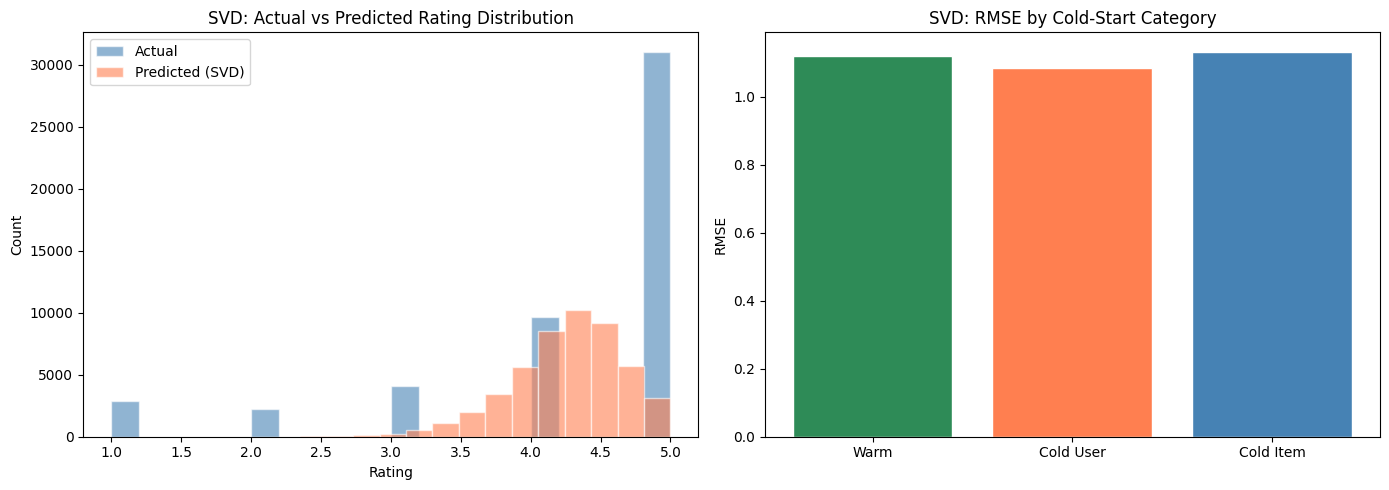

  Warm        : RMSE=1.1193 (305,900 predictions)
  Cold User   : RMSE=1.0851 (79,934 predictions)
  Cold Item   : RMSE=1.1331 (42,571 predictions)


In [15]:
# ── CF Visualization ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Predicted vs actual distribution for SVD
svd_actual = [p.r_ui for p in preds_svd[:50000]]
svd_pred   = [p.est for p in preds_svd[:50000]]

axes[0].hist(svd_actual, bins=20, alpha=0.6, label='Actual', color='steelblue', edgecolor='white')
axes[0].hist(svd_pred, bins=20, alpha=0.6, label='Predicted (SVD)', color='coral', edgecolor='white')
axes[0].set_title('SVD: Actual vs Predicted Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Cold-start analysis
warm_preds = [p for p in preds_svd if p.uid in train_users and p.iid in train_items]
cold_user_preds = [p for p in preds_svd if p.uid not in train_users]
cold_item_preds = [p for p in preds_svd if p.iid not in train_items]

cold_data = {
    'Warm': rmse([p.r_ui for p in warm_preds], [p.est for p in warm_preds]) if warm_preds else 0,
    'Cold User': rmse([p.r_ui for p in cold_user_preds], [p.est for p in cold_user_preds]) if cold_user_preds else 0,
    'Cold Item': rmse([p.r_ui for p in cold_item_preds], [p.est for p in cold_item_preds]) if cold_item_preds else 0,
}
axes[1].bar(cold_data.keys(), cold_data.values(), color=['seagreen', 'coral', 'steelblue'], edgecolor='white')
axes[1].set_title('SVD: RMSE by Cold-Start Category')
axes[1].set_ylabel('RMSE')

plt.tight_layout()
plt.show()

for cat, val in cold_data.items():
    count = len(warm_preds) if cat == 'Warm' else (len(cold_user_preds) if cat == 'Cold User' else len(cold_item_preds))
    print(f"  {cat:12s}: RMSE={val:.4f} ({count:,} predictions)")

## 5. Content-Based Recommender

The content-based approach recommends items based on **metadata similarity** rather than collaborative patterns. For each item, we build a feature vector from:

- **Text features** — TF-IDF on title and description (5,000 dimensions)
- **Categories** — multi-hot encoding of product categories (top 500)
- **Brand** — one-hot encoding (top 100 brands + "other")
- **Price** — normalized to [0,1]

For prediction: given a target item, we find the K most content-similar items among those the user has rated, then predict the rating as a similarity-weighted average.

**Key advantage over CF**: Content-based can handle **cold-start items** (new products with metadata but no ratings) since it does not depend on historical interactions.

In [16]:
# ── Content-Based: Feature Engineering (Text) ────────────────

# Merge metadata with item IDs from our training set
meta = df_meta_filtered.copy()
meta = meta.rename(columns={'asin': 'item_id'})
meta = meta.drop_duplicates(subset='item_id')

# Ensure all train items have metadata (fill missing with empty)
all_train_items_list = list(train_items)
meta = meta.set_index('item_id').reindex(all_train_items_list).reset_index()

# Fill missing text
meta['title'] = meta['title'].fillna('')
meta['description'] = meta['description'].fillna('')
meta['text'] = meta['title'] + ' ' + meta['description']

# TF-IDF
print("Building TF-IDF matrix...")
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', sublinear_tf=True, dtype=np.float32)
tfidf_matrix = tfidf.fit_transform(meta['text'])

print(f"TF-IDF matrix: {tfidf_matrix.shape} (items x features)")
print(f"Non-zero entries: {tfidf_matrix.nnz:,} ({100*tfidf_matrix.nnz/(tfidf_matrix.shape[0]*tfidf_matrix.shape[1]):.2f}% dense)")

Building TF-IDF matrix...
TF-IDF matrix: (134463, 5000) (items x features)
Non-zero entries: 6,981,273 (1.04% dense)


In [ ]:
# ── Content-Based: Feature Engineering (Categories, Brand, Price) ──

# Parse categories
def parse_categories(cat_str):
    try:
        cats = ast.literal_eval(str(cat_str))
        # Flatten nested lists and take leaf categories
        leaves = []
        if isinstance(cats, list):
            for path in cats:
                if isinstance(path, list) and len(path) > 0:
                    leaves.append(path[-1])  # leaf category
        return leaves
    except:
        return []

meta['parsed_cats'] = meta['categories'].apply(parse_categories)

# Multi-hot encode top 500 categories
from collections import Counter
all_cats = [c for cats in meta['parsed_cats'] for c in cats]
top_cats = [c for c, _ in Counter(all_cats).most_common(500)]
top_cats_set = set(top_cats)
meta['filtered_cats'] = meta['parsed_cats'].apply(lambda x: [c for c in x if c in top_cats_set])

mlb = MultiLabelBinarizer(classes=top_cats, sparse_output=True)
cat_matrix = mlb.fit_transform(meta['filtered_cats'])
print(f"Category matrix: {cat_matrix.shape}")

# Brand: top 100 + 'other'
meta['brand'] = meta['brand'].fillna('Unknown')
top_brands = meta['brand'].value_counts().head(100).index.tolist()
meta['brand_clean'] = meta['brand'].apply(lambda x: x if x in top_brands else 'Other')
brand_dummies = pd.get_dummies(meta['brand_clean'], sparse=True, dtype=np.float32)
brand_matrix = csr_matrix(brand_dummies.values)
print(f"Brand matrix: {brand_matrix.shape}")

# Price: normalize
meta['price'] = pd.to_numeric(meta['price'], errors='coerce')
meta['price'] = meta['price'].fillna(meta['price'].median())
price_norm = MinMaxScaler().fit_transform(meta[['price']].values)
price_matrix = csr_matrix(price_norm, dtype=np.float32)
print(f"Price matrix: {price_matrix.shape}")

# ── Combine all features ─────────────────────────────────────
item_features = hstack([tfidf_matrix, cat_matrix, brand_matrix, price_matrix]).tocsr()
print(f"\nCombined item feature matrix: {item_features.shape}")
print(f"Total non-zero entries: {item_features.nnz:,}")

# Build item_id → index mapping
item_to_idx = {item: i for i, item in enumerate(all_train_items_list)}
idx_to_item = {i: item for item, i in item_to_idx.items()}

gc.collect()
print("Feature engineering complete.")

In [18]:
# ── Content-Based: Prediction Model ──────────────────────────

# Precompute item stats for cold-start fallback
item_stats = train_df.groupby('item_id')['rating'].agg(['count', 'mean'])
m = 50
item_stats['damped_score'] = (item_stats['count'] * item_stats['mean'] + m * GLOBAL_MEAN) / (item_stats['count'] + m)

# Precompute nearest neighbors in content space for efficiency
print("Fitting NearestNeighbors on item features...")
nn_model = NearestNeighbors(n_neighbors=50, metric='cosine', algorithm='brute', n_jobs=-1)
nn_model.fit(item_features)
print("Done.")

# Precompute user training data: {user_id: [(item_idx, rating), ...]}
train_user_data = {}
for user_id, group in train_df.groupby('user_id'):
    items_ratings = []
    for _, row in group.iterrows():
        if row['item_id'] in item_to_idx:
            items_ratings.append((item_to_idx[row['item_id']], row['rating']))
    if items_ratings:
        train_user_data[user_id] = items_ratings

def predict_content_based(user_id, item_id, k=20):
    """Predict rating using content-based KNN."""
    if item_id not in item_to_idx:
        return GLOBAL_MEAN
    if user_id not in train_user_data:
        # Cold-start user fallback to damped popularity
        if item_id in item_stats.index:
            return item_stats.loc[item_id, 'damped_score']
        return GLOBAL_MEAN

    target_idx = item_to_idx[item_id]
    user_items = train_user_data[user_id]
    user_idxs = [idx for idx, _ in user_items]
    user_ratings = [r for _, r in user_items]

    # Compute cosine similarity between target item and user's rated items
    target_feat = item_features[target_idx]
    user_feat = item_features[user_idxs]
    sims = sk_cosine(target_feat, user_feat).flatten()

    # Top-k most similar items the user has rated
    if len(sims) > k:
        top_k_indices = np.argsort(sims)[-k:]
    else:
        top_k_indices = np.arange(len(sims))

    top_sims = sims[top_k_indices]
    top_ratings = np.array(user_ratings)[top_k_indices]

    # Filter out zero/negative similarities
    mask = top_sims > 0
    if mask.sum() == 0:
        return GLOBAL_MEAN

    pred = np.average(top_ratings[mask], weights=top_sims[mask])
    return np.clip(pred, 1.0, 5.0)

def get_cb_top_k(user_id, k=K):
    """Generate top-K content-based recommendations."""
    seen = train_user_items.get(user_id, set())
    if user_id not in train_user_data:
        return [it for it in top_items_damped if it not in seen][:k]

    user_items = train_user_data[user_id]
    user_idxs = [idx for idx, _ in user_items]
    user_ratings_arr = np.array([r - GLOBAL_MEAN for _, r in user_items])

    user_profile = csr_matrix(user_ratings_arr.reshape(1, -1)) @ item_features[user_idxs]

    distances, indices = nn_model.kneighbors(user_profile, n_neighbors=k + len(seen))
    recs = []
    for idx in indices.flatten():
        item_id = idx_to_item.get(idx)
        if item_id and item_id not in seen:
            recs.append(item_id)
        if len(recs) >= k:
            break
    return recs

print(f"Content-based predictor ready. Users with profiles: {len(train_user_data):,}")

Fitting NearestNeighbors on item features...
Done.
Content-based predictor ready. Users with profiles: 241,268


In [ ]:
# ── Content-Based Evaluation (Optimized Sample) ──────────────────

# Reducimos la muestra para evitar que la celda se cuelgue en Colab
TEST_SAMPLE_SIZE = 100000
RANKING_SAMPLE_SIZE = 1000

print(f"Evaluating Content-Based on test sample ({TEST_SAMPLE_SIZE:,} interactions)... ")
test_sample = test_df.sample(n=min(TEST_SAMPLE_SIZE, len(test_df)), random_state=42)

actual_cb, predicted_cb = [], []
for _, row in test_sample.iterrows():
    actual_cb.append(row['rating'])
    predicted_cb.append(predict_content_based(row['user_id'], row['item_id']))

rmse_cb = rmse(actual_cb, predicted_cb)
mae_cb  = mae(actual_cb, predicted_cb)
print(f"  Content-Based — RMSE: {rmse_cb:.4f}, MAE: {mae_cb:.4f}")

# Ranking metrics con muestra reducida
print(f"\nComputing ranking metrics for {RANKING_SAMPLE_SIZE} users...")
sample_users_cb = np.random.choice(SAMPLE_USERS, size=min(RANKING_SAMPLE_SIZE, len(SAMPLE_USERS)), replace=False)

all_recs_cb = []
prec_scores_cb, rec_scores_cb, ndcg_scores_cb = [], [], []

for user_id in sample_users_cb:
    recs = get_cb_top_k(user_id)
    all_recs_cb.append(recs)
    relevant = test_user_relevant.get(user_id, set())
    rel_ratings = {it: r for it, r in test_user_ratings.get(user_id, {}).items() if r >= RELEVANCE_THRESHOLD}
    prec_scores_cb.append(precision_at_k(recs, relevant))
    rec_scores_cb.append(recall_at_k(recs, relevant))
    ndcg_scores_cb.append(ndcg_at_k(recs, rel_ratings))

cov_cb = coverage(all_recs_cb, ALL_ITEMS)

print("Computing Diversity (Intra-list similarity)... ")
div_cb = diversity_intra_list(all_recs_cb, item_features, item_to_idx)

results_cb = {
    'RMSE': rmse_cb, 'MAE': mae_cb,
    'Precision@10': np.mean(prec_scores_cb), 'Recall@10': np.mean(rec_scores_cb),
    'NDCG@10': np.mean(ndcg_scores_cb), 'Coverage': cov_cb, 'Diversity': div_cb
}

print(f"\nFINAL CB RESULTS:")
print(f"  P@10={results_cb['Precision@10']:.4f} | R@10={results_cb['Recall@10']:.4f} | "
      f"NDCG@10={results_cb['NDCG@10']:.4f} | Cov={cov_cb:.4f} | Div={div_cb:.4f}")

print("\nContent-based evaluation complete.")

Evaluating Content-Based on test sample (100,000 interactions)... 
  Content-Based — RMSE: 1.3364, MAE: 0.9265

Computing ranking metrics for 1000 users...
Computing Diversity (Intra-list similarity)... 

FINAL CB RESULTS:
  P@10=0.0010 | R@10=0.0041 | NDCG@10=0.0028 | Cov=0.0543 | Div=0.3398

Content-based evaluation complete.


Example Content-Based Recommendations for user A3UJ81SR3S4LJA:
  (User rated 11 items in training)
  1. Guardian Biker Bell Hanger (B004GW5FEY)
  2. Lumiquest Promax System (B00009XW5J)
  3. Ambient Weather WR-089 Compact Emergency Solar Han (B004068AWU)
  4. Ambient Weather WR-089-AC Emergency Solar Hand Cra (B00B9IH15Y)
  5. Ambient Weather WR-333 Emergency Solar Hand Crank  (B009NUK6S4)

Cold-start items — CB RMSE: 1.1662, SVD RMSE: 1.1280


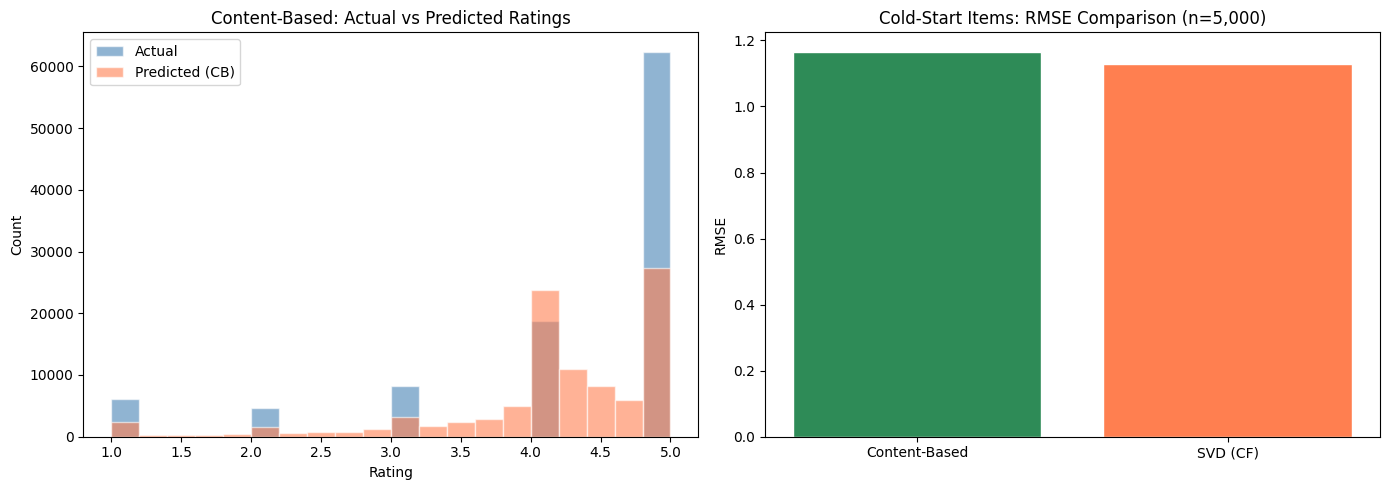

In [ ]:
# ── Content-Based Visualization ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Example recommendations for a random user
example_user = SAMPLE_USERS[0]
example_recs = get_cb_top_k(example_user, k=5)

# Show recommended items with metadata
rec_info = []
for item_id in example_recs:
    row = meta[meta['item_id'] == item_id].iloc[0] if item_id in meta['item_id'].values else None
    title = row['title'][:50] if row is not None and pd.notna(row['title']) else 'Unknown'
    rec_info.append({'item_id': item_id, 'title': title})

print(f"Example Content-Based Recommendations for user {example_user}:")
print(f"  (User rated {len(train_user_data.get(example_user, [])):,} items in training)")
for i, info in enumerate(rec_info, 1):
    print(f"  {i}. {info['title']} ({info['item_id']})")

# Actual vs predicted distribution
axes[0].hist(actual_cb, bins=20, alpha=0.6, label='Actual', color='steelblue', edgecolor='white')
axes[0].hist(predicted_cb, bins=20, alpha=0.6, label='Predicted (CB)', color='coral', edgecolor='white')
axes[0].set_title('Content-Based: Actual vs Predicted Ratings')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].legend()

# Cold-start items: CB vs CF
cold_item_test = test_df[test_df['item_id'].isin(cold_items)].sample(n=min(5000, len(test_df[test_df['item_id'].isin(cold_items)])), random_state=42)
if len(cold_item_test) > 0:
    cb_cold_rmse = rmse(
        cold_item_test['rating'].tolist(),
        [predict_content_based(r.user_id, r.item_id) for _, r in cold_item_test.iterrows()]
    )
    svd_cold_rmse = rmse(
        cold_item_test['rating'].tolist(),
        [algo_svd.predict(r.user_id, r.item_id).est for _, r in cold_item_test.iterrows()]
    )
    axes[1].bar(['Content-Based', 'SVD (CF)'], [cb_cold_rmse, svd_cold_rmse],
                color=['seagreen', 'coral'], edgecolor='white')
    axes[1].set_title(f'Cold-Start Items: RMSE Comparison (n={len(cold_item_test):,})')
    axes[1].set_ylabel('RMSE')
    print(f"\nCold-start items — CB RMSE: {cb_cold_rmse:.4f}, SVD RMSE: {svd_cold_rmse:.4f}")

plt.tight_layout()
plt.show()

Running t-SNE (this may take a minute)...


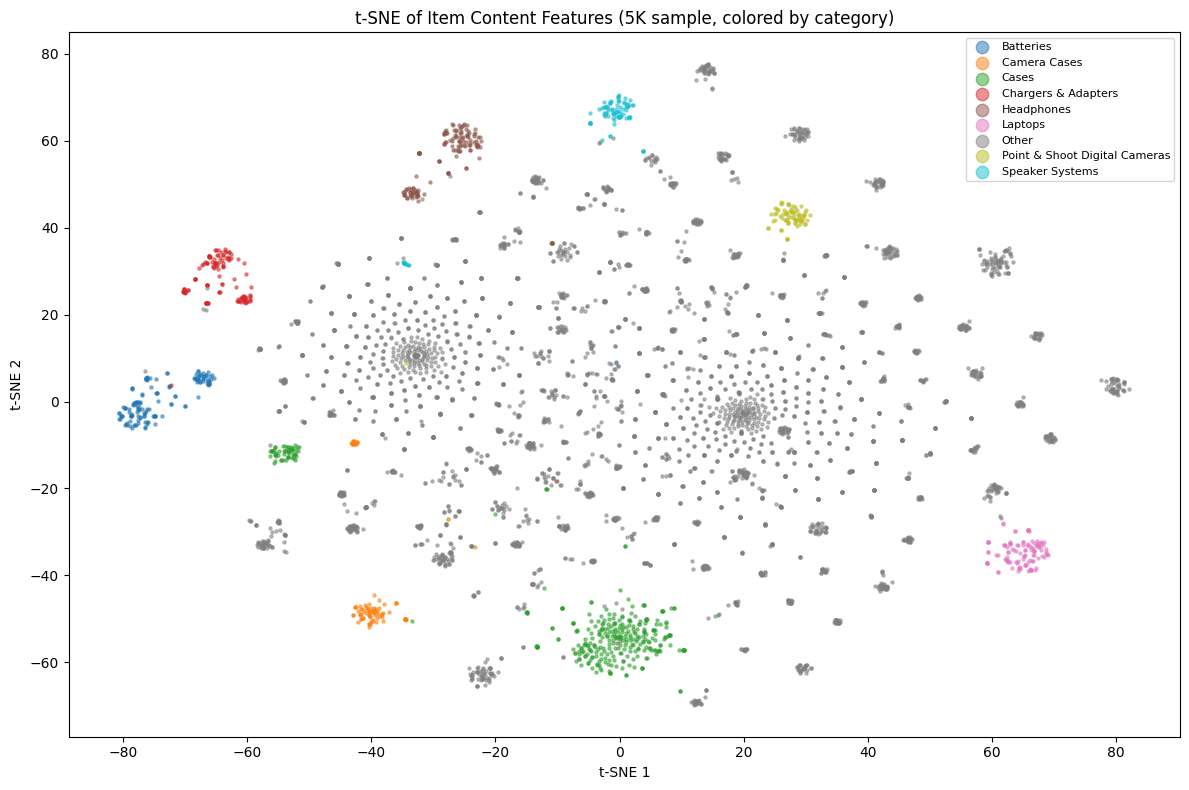

t-SNE visualization complete.


In [ ]:
# ── Item Embedding Visualization (t-SNE) ─────────────────────
from sklearn.manifold import TSNE

# Sample 5000 items for visualization
sample_size = 5000
sample_idxs = np.random.choice(len(all_train_items_list), size=sample_size, replace=False)
sample_features = item_features[sample_idxs].toarray()

# Get top-level category for coloring
sample_top_cats = []
for idx in sample_idxs:
    cats = meta.iloc[idx]['parsed_cats'] if idx < len(meta) else []
    if cats:
        sample_top_cats.append(cats[0])
    else:
        sample_top_cats.append('Unknown')

# Keep top 8 categories for color, rest as 'Other'
from collections import Counter
cat_counts = Counter(sample_top_cats)
top_8_cats = [c for c, _ in cat_counts.most_common(8)]
sample_colors = [c if c in top_8_cats else 'Other' for c in sample_top_cats]

print("Running t-SNE (this may take a minute)...")
tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
embeddings = tsne.fit_transform(sample_features)

plt.figure(figsize=(12, 8))
unique_cats = sorted(set(sample_colors))
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_cats)))
for i, cat in enumerate(unique_cats):
    mask = [c == cat for c in sample_colors]
    plt.scatter(embeddings[mask, 0], embeddings[mask, 1], s=5, alpha=0.5,
                label=cat, color=colors[i])
plt.legend(markerscale=4, fontsize=8, loc='best')
plt.title('t-SNE of Item Content Features (5K sample, colored by category)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.tight_layout()
plt.show()
print("t-SNE visualization complete.")

## 6. Context-Aware Recommender

The context-aware recommender incorporates **temporal context** — time-based features that capture *when* a user interacts with items — to improve predictions beyond what static user-item models achieve.

**Context variables used:**
- **Month of year** (1–12) — captures seasonal purchasing patterns (e.g., holiday electronics spikes in Nov–Dec)
- **Day of week** (0=Mon … 6=Sun) — captures weekday vs. weekend browsing behavior
- **Time period** — early / mid / late in the dataset timeline, capturing evolving user preferences

**Approach:** We train an SVD model on residuals after removing context-based biases. For each interaction, we compute a context bias from the combination of (month, day-of-week, time-period), then train SVD on the de-biased ratings. At prediction time, we add the context bias back to the SVD estimate.

This is a **pre/post-filtering hybrid**: context biases are estimated first (pre-processing), then the latent factor model captures remaining user-item patterns, and context is re-applied at scoring time.

**Key advantage:** User ratings are not uniform across time — a product reviewed during holiday season may receive systematically different ratings than the same product reviewed in a quiet month.


In [ ]:
# ── Context-Aware: Feature Engineering ────────────────────────
import time

# Ensure temporal features exist in train/test
for df in [train_df, test_df]:
    if 'datetime' not in df.columns:
        df['datetime'] = pd.to_datetime(df['timestamp'], unit='s')
    if 'month' not in df.columns:
        df['month'] = df['datetime'].dt.month
    if 'dayofweek' not in df.columns:
        df['dayofweek'] = df['datetime'].dt.dayofweek
    if 'year' not in df.columns:
        df['year'] = df['datetime'].dt.year

# Create time period bins (early / mid / late)
train_min_ts = train_df['timestamp'].min()
train_max_ts = train_df['timestamp'].max()
ts_range = train_max_ts - train_min_ts

def get_time_period(ts):
    frac = (ts - train_min_ts) / ts_range
    if frac < 0.33:
        return 'early'
    elif frac < 0.66:
        return 'mid'
    else:
        return 'late'

train_df['time_period'] = train_df['timestamp'].apply(get_time_period)
test_df['time_period'] = test_df['timestamp'].apply(
    lambda ts: get_time_period(min(ts, train_max_ts))
)

# Context key: (month, dayofweek, time_period)
train_df['context_key'] = list(zip(train_df['month'], train_df['dayofweek'], train_df['time_period']))
test_df['context_key'] = list(zip(test_df['month'], test_df['dayofweek'], test_df['time_period']))

print("=== CONTEXT FEATURE SUMMARY ===")
print(f"Unique context keys (train): {train_df['context_key'].nunique()}")

print(f"\nRatings by day of week (train):")
dow_names = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
dow_stats = train_df.groupby('dayofweek')['rating'].agg(['mean', 'count'])
for dow, row in dow_stats.iterrows():
    print(f"  {dow_names[dow]}: avg={row['mean']:.3f}  n={int(row['count']):,}")

print(f"\nRatings by time period (train):")
tp_stats = train_df.groupby('time_period')['rating'].agg(['mean', 'count'])
for tp, row in tp_stats.iterrows():
    print(f"  {tp:5s}: avg={row['mean']:.3f}  n={int(row['count']):,}")


=== CONTEXT FEATURE SUMMARY ===
Unique context keys (train): 252

Ratings by day of week (train):
  Mon: avg=4.179  n=254,730
  Tue: avg=4.176  n=253,349
  Wed: avg=4.176  n=258,341
  Thu: avg=4.180  n=255,606
  Fri: avg=4.177  n=239,869
  Sat: avg=4.172  n=215,094
  Sun: avg=4.180  n=210,906

Ratings by time period (train):
  early: avg=4.032  n=15,661
  late : avg=4.192  n=1,512,592
  mid  : avg=4.050  n=159,642


In [ ]:
# ── Context-Aware: Bias Estimation + Residual SVD ─────────────
from surprise import SVD, Dataset, Reader, accuracy

# Step 1: Compute context biases from training data
# bias(context) = mean_rating(context) - global_mean
context_bias = train_df.groupby('context_key')['rating'].mean().to_dict()
context_bias = {k: v - GLOBAL_MEAN for k, v in context_bias.items()}

print(f"Context biases computed for {len(context_bias)} unique contexts")
print(f"Bias range: [{min(context_bias.values()):.4f}, {max(context_bias.values()):.4f}]")

# Step 2: Remove context bias from training ratings
train_df['context_bias'] = train_df['context_key'].map(context_bias).fillna(0.0)
train_df['rating_debiased'] = (train_df['rating'] - train_df['context_bias']).clip(1.0, 5.0)

# Step 3: Train SVD on de-biased ratings
print("\nTraining SVD on context-debiased ratings (30 factors, 20 epochs)...")
t0 = time.time()

reader_ctx = Reader(rating_scale=(1.0, 5.0))
train_ctx_surprise = Dataset.load_from_df(
    train_df[['user_id', 'item_id', 'rating_debiased']].rename(columns={'rating_debiased': 'rating'}),
    reader_ctx
).build_full_trainset()

algo_ctx = SVD(n_factors=30, n_epochs=20, lr_all=0.005, reg_all=0.02, random_state=42)
algo_ctx.fit(train_ctx_surprise)
print(f"  Done in {time.time()-t0:.1f}s")

# Step 4: Prediction function
def predict_context_aware(user_id, item_id, context_key):
    """Predict rating = SVD(debiased) + context_bias."""
    svd_pred = algo_ctx.predict(user_id, item_id).est
    bias = context_bias.get(context_key, 0.0)
    return np.clip(svd_pred + bias, 1.0, 5.0)

def get_context_top_k(user_id, context_key, k=K):
    """Generate top-K context-aware recommendations."""
    seen = train_user_items.get(user_id, set())
    candidates = [it for it in train_items if it not in seen]
    if len(candidates) > 2000:
        candidates = list(np.random.choice(candidates, 2000, replace=False))
    scores = [(it, predict_context_aware(user_id, it, context_key)) for it in candidates]
    scores.sort(key=lambda x: x[1], reverse=True)
    return [it for it, _ in scores[:k]]

print("Context-aware predictor ready.")


Context biases computed for 252 unique contexts
Bias range: [-0.3601, 0.0758]

Training SVD on context-debiased ratings (30 factors, 20 epochs)...
  Done in 28.8s
Context-aware predictor ready.


In [ ]:
# ── Context-Aware Evaluation ──────────────────────────────────
print("Evaluating Context-Aware on full test set (rating prediction)...")

# Rating prediction (vectorized via list comprehension on itertuples for speed)
actual_ctx = test_df['rating'].tolist()
predicted_ctx = [
    predict_context_aware(row.user_id, row.item_id, row.context_key)
    for row in test_df.itertuples()
]
rmse_ctx = rmse(actual_ctx, predicted_ctx)
mae_ctx = mae(actual_ctx, predicted_ctx)
print(f"  Context-Aware — RMSE: {rmse_ctx:.4f}, MAE: {mae_ctx:.4f}")
print(f"  Vanilla SVD   — RMSE: {rmse_svd:.4f}, MAE: {mae_svd:.4f}")
print(f"  Improvement   — RMSE: {rmse_svd - rmse_ctx:+.4f}, MAE: {mae_svd - mae_ctx:+.4f}")

# Ranking metrics
RANKING_SAMPLE_CTX = min(1000, len(SAMPLE_USERS))
sample_users_ctx = np.random.choice(SAMPLE_USERS, size=RANKING_SAMPLE_CTX, replace=False)

print(f"\nComputing ranking metrics for {RANKING_SAMPLE_CTX} users...")
all_recs_ctx = []
prec_ctx, rec_ctx, ndcg_ctx = [], [], []

for user_id in sample_users_ctx:
    # Use the user's most recent context from test set
    user_test = test_df[test_df['user_id'] == user_id]
    if len(user_test) > 0:
        ctx_key = user_test.iloc[-1]['context_key']
    else:
        ctx_key = (6, 3, 'late')  # default fallback

    recs = get_context_top_k(user_id, ctx_key)
    all_recs_ctx.append(recs)

    relevant = test_user_relevant.get(user_id, set())
    rel_ratings = {it: r for it, r in test_user_ratings.get(user_id, {}).items() if r >= RELEVANCE_THRESHOLD}
    prec_ctx.append(precision_at_k(recs, relevant))
    rec_ctx.append(recall_at_k(recs, relevant))
    ndcg_ctx.append(ndcg_at_k(recs, rel_ratings))

cov_ctx = coverage(all_recs_ctx, ALL_ITEMS)
div_ctx = diversity_intra_list(all_recs_ctx, item_features, item_to_idx)

results_ctx = {
    'RMSE': rmse_ctx, 'MAE': mae_ctx,
    'Precision@10': np.mean(prec_ctx), 'Recall@10': np.mean(rec_ctx),
    'NDCG@10': np.mean(ndcg_ctx), 'Coverage': cov_ctx, 'Diversity': div_ctx
}

print(f"  P@10={results_ctx['Precision@10']:.4f} | R@10={results_ctx['Recall@10']:.4f} | "
      f"NDCG@10={results_ctx['NDCG@10']:.4f} | Cov={cov_ctx:.4f} | Div={div_ctx:.4f}")
print("\nContext-aware evaluation complete.")


Evaluating Context-Aware on full test set (rating prediction)...
  Context-Aware — RMSE: 1.1138, MAE: 0.8366
  Vanilla SVD   — RMSE: 1.1138, MAE: 0.8393
  Improvement   — RMSE: -0.0001, MAE: +0.0027

Computing ranking metrics for 1000 users...
  P@10=0.0002 | R@10=0.0006 | NDCG@10=0.0003 | Cov=0.0208 | Div=0.9041

Context-aware evaluation complete.


In [ ]:
# ── Context-Aware Visualization ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Context-Aware Recommender Analysis', fontsize=14, fontweight='bold')

# 1. Context bias by month
monthly_bias = train_df.groupby('month').apply(
    lambda x: x['rating'].mean() - GLOBAL_MEAN
)
month_labels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
colors_month = ['coral' if b > 0 else 'steelblue' for b in monthly_bias.values]
axes[0,0].bar(range(1, 13), monthly_bias.values, color=colors_month, edgecolor='white')
axes[0,0].set_xticks(range(1, 13))
axes[0,0].set_xticklabels(month_labels, fontsize=9)
axes[0,0].set_title('Rating Bias by Month')
axes[0,0].set_ylabel('Bias (vs global mean)')
axes[0,0].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# 2. Context bias by day of week
dow_bias = train_df.groupby('dayofweek').apply(
    lambda x: x['rating'].mean() - GLOBAL_MEAN
)
dow_labels = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
colors_dow = ['coral' if b > 0 else 'steelblue' for b in dow_bias.values]
axes[0,1].bar(range(7), dow_bias.values, color=colors_dow, edgecolor='white')
axes[0,1].set_xticks(range(7))
axes[0,1].set_xticklabels(dow_labels)
axes[0,1].set_title('Rating Bias by Day of Week')
axes[0,1].set_ylabel('Bias (vs global mean)')
axes[0,1].axhline(y=0, color='gray', linestyle='--', linewidth=0.5)

# 3. Actual vs Predicted distribution
axes[1,0].hist(actual_ctx[:50000], bins=20, alpha=0.6, label='Actual', color='steelblue', edgecolor='white')
axes[1,0].hist(predicted_ctx[:50000], bins=20, alpha=0.6, label='Predicted (Ctx)', color='coral', edgecolor='white')
axes[1,0].set_title('Context-Aware: Actual vs Predicted')
axes[1,0].set_xlabel('Rating')
axes[1,0].set_ylabel('Count')
axes[1,0].legend()

# 4. RMSE comparison across all models
model_names = ['Global Mean', 'Damped Mean', 'SVD (CF)', 'Content-Based', 'Context-Aware']
rmse_values = [
    results_np.get('Global Mean', {}).get('RMSE', 0),
    results_np.get('Damped Mean', {}).get('RMSE', 0),
    rmse_svd,
    rmse_cb,
    rmse_ctx
]
bar_colors = ['gray', 'gray', 'steelblue', 'seagreen', 'coral']
axes[1,1].barh(model_names, rmse_values, color=bar_colors, edgecolor='white')
axes[1,1].set_title('RMSE Comparison Across All Models')
axes[1,1].set_xlabel('RMSE')
axes[1,1].invert_yaxis()

plt.tight_layout()
plt.show()
print("Context-aware visualization complete.")
